In [1]:

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
import matplotlib.patches as patches

In [2]:
# 1. بارگذاری دیتاست Iris
iris = load_iris()
X = iris.data[:, :2]  # فقط دو ویژگی اول: طول و عرض کاسبرگ
y = iris.target
feature_names = iris.feature_names[:2]
target_names = iris.target_names

In [3]:
import pandas as pd

In [ ]:
# *. اختیاری برای تبدیل کردن iris به دیتا فریم
iris


In [4]:
data = pd.DataFrame(iris.data, columns = iris.feature_names)

data["target"] = iris.target
data["target_name"] = data["target"].apply(lambda x: iris.target_names[x])

data.describe()
data.sample(10)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,target_name
73,6.1,2.8,4.7,1.2,1,versicolor
58,6.6,2.9,4.6,1.3,1,versicolor
59,5.2,2.7,3.9,1.4,1,versicolor
4,5.0,3.6,1.4,0.2,0,setosa
138,6.0,3.0,4.8,1.8,2,virginica
29,4.7,3.2,1.6,0.2,0,setosa
46,5.1,3.8,1.6,0.2,0,setosa
78,6.0,2.9,4.5,1.5,1,versicolor
1,4.9,3.0,1.4,0.2,0,setosa
85,6.0,3.4,4.5,1.6,1,versicolor


In [5]:
# 2. نرمال‌سازی داده‌ها (اختیاری ولی پیشنهادی)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [6]:
# 3. تعریف یک نقطه جدید (مثلاً طول=5.2، عرض=3.6)
new_point = np.array([[5.2, 3.6]])
new_point_scaled = scaler.transform(new_point)

In [15]:

# 4. یافتن K=5 همسایه نزدیک
k = 7
nbrs = NearestNeighbors(n_neighbors=k, metric='euclidean').fit(X_scaled)
distances, indices = nbrs.kneighbors(new_point_scaled)

In [16]:
# 5. نمایش نتایج
print("نقطه جدید:", new_point[0])
print("۵ همسایه نزدیک (شاخص‌ها):", indices[0])
print("فاصله‌ها:", distances[0])
print("کلاس همسایگان:", y[indices[0]])

نقطه جدید: [5.2 3.6]
۵ همسایه نزدیک (شاخص‌ها): [27  4 48 17  0 21 43]
فاصله‌ها: [0.23019677 0.24233574 0.26013882 0.26013882 0.26013882 0.26013882
 0.33424117]
کلاس همسایگان: [0 0 0 0 0 0 0]


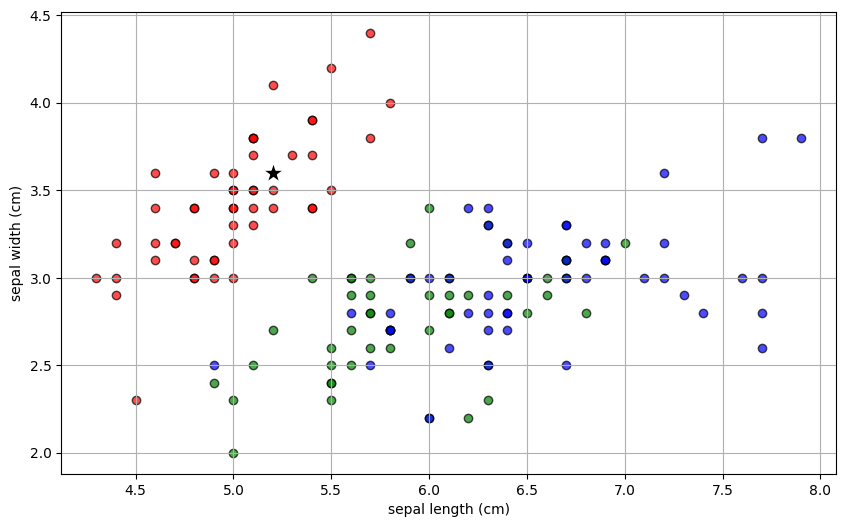

In [17]:
# 6. رسم نمودار
plt.figure(figsize=(10, 6))
plt.grid(True)
# رنگ‌بندی کلاس‌ها
colors = ['red', 'green', 'blue']
for i, class_name in enumerate(target_names):
    mask = (y == i)
    plt.xlabel(feature_names[0])   # طول کاسبرگ
    plt.ylabel(feature_names[1])   # عرض کاسبرگ
    plt.scatter(X[mask, 0], X[mask, 1], 
                c=colors[i], label=class_name, alpha=0.7, edgecolors='k')

plt.scatter(new_point[0, 0], new_point[0, 1],
            c='black', marker='*', s=300,
            edgecolors='white', linewidth=1.5,
            label='نقطه جدید (Query)')
    

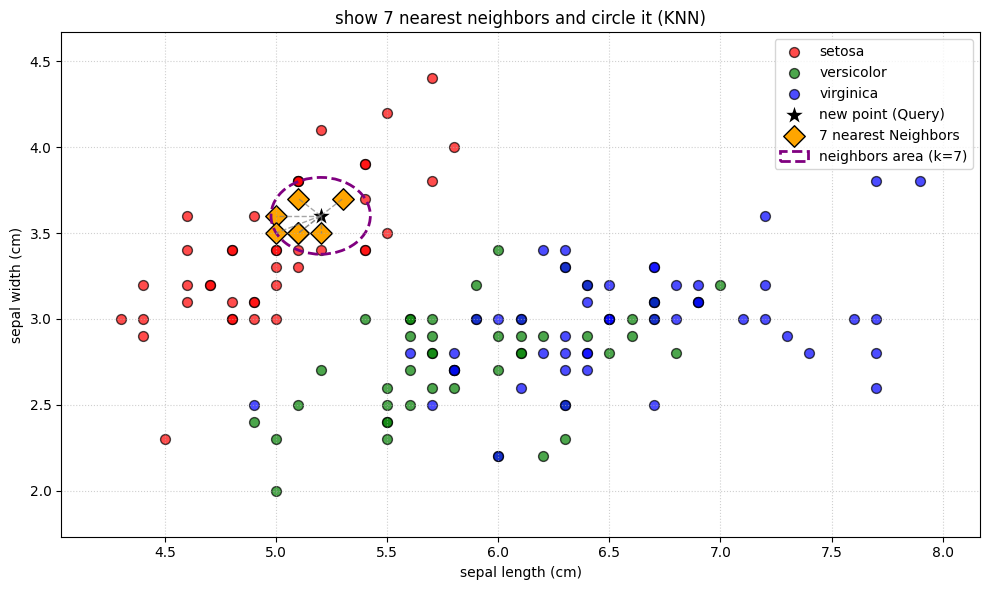

In [18]:
plt.figure(figsize=(10, 6))

# رنگ‌بندی کلاس‌ها
colors = ['red', 'green', 'blue']
for i, class_name in enumerate(target_names):
    mask = (y == i)
    plt.scatter(X[mask, 0], X[mask, 1],
                c=colors[i], label=class_name,
                alpha=0.7, edgecolors='k', s=50)

# نقطه جدید
plt.scatter(new_point[0, 0], new_point[0, 1],
            c='black', marker='*', s=300,
            edgecolors='white', linewidth=1.5,
            label='new point (Query)')

# همسایگان
neighbors = X[indices[0]]
plt.scatter(neighbors[:, 0], neighbors[:, 1],
            c='orange', marker='D', s=120,
            edgecolors='black', linewidth=1,
            label=f'{k} nearest Neighbors')

# خطوط اتصال
for i in range(k):
    plt.plot([new_point[0, 0], neighbors[i, 0]],
             [new_point[0, 1], neighbors[i, 1]],
             'gray', linestyle='--', linewidth=1, alpha=0.7)

#  رسم دایره بر اساس K انتخاب شده 
# محاسبه فاصله نقطه جدید تا دورترین همسایه (در فضای اصلی)
distances_original = []
for i in range(k):
    d = np.sqrt((new_point[0,0] - neighbors[i,0])**2 + (new_point[0,1] - neighbors[i,1])**2)
    distances_original.append(d)
radius = max(distances_original)   # شعاع = فاصله تا دورترین همسایه

# اضافه کردن دایره به نمودار
circle = patches.Circle((new_point[0,0], new_point[0,1]),
                        radius=radius,
                        edgecolor='purple', facecolor='none',
                        linestyle='--', linewidth=2, label=f'neighbors area (k={k})')
plt.gca().add_patch(circle)

# تنظیمات نمودار
plt.xlabel(feature_names[0])
plt.ylabel(feature_names[1])
plt.title(f'show {k} nearest neighbors and circle it (KNN)')

# تنظیم محدوده محورها برای دیده شدن کامل دایره
all_x = np.append(X[:, 0], new_point[0, 0])
all_y = np.append(X[:, 1], new_point[0, 1])
margin = radius * 1.2
plt.xlim(all_x.min() - margin, all_x.max() + margin)
plt.ylim(all_y.min() - margin, all_y.max() + margin)

plt.legend(loc='best')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()


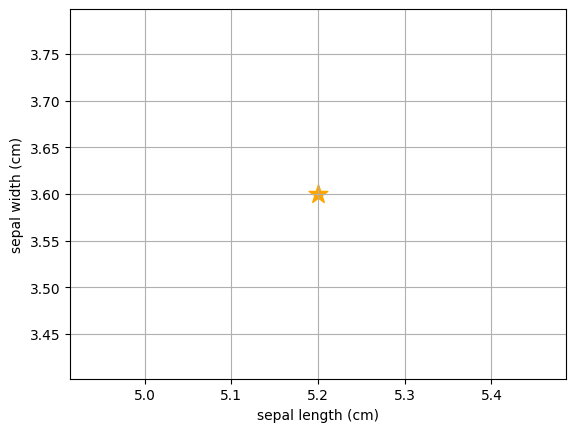

In [19]:
# نقطه جدید
plt.xlabel(feature_names[0])   # طول کاسبرگ
plt.ylabel(feature_names[1])   # عرض کاسبرگ
plt.grid(True)
plt.scatter(new_point[0,0], new_point[0,1], 
            c='orange', marker='*', s=200, label='نقطه جدید (Query)')

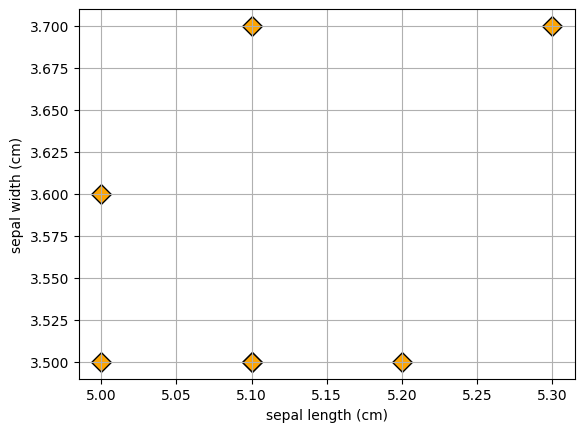

In [20]:
# همسایگان
neighbors = X[indices[0]]
plt.xlabel(feature_names[0])   # طول کاسبرگ
plt.ylabel(feature_names[1])   # عرض کاسبرگ
plt.grid(True)
plt.scatter(neighbors[:,0], neighbors[:,1], 
            c='orange', marker='D', s=100, label=f'{k} همسایه نزدیک', edgecolors='black')

C:\Users\noobm\AppData\Local\Temp\ipykernel_8972\1988890223.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


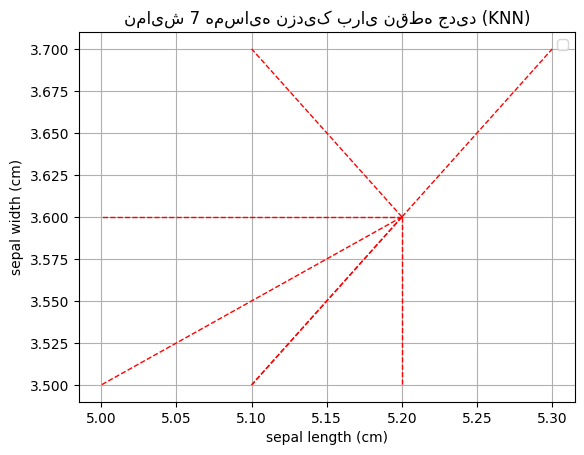

In [21]:
# خطوط کمکی (اختیاری) برای اتصال نقطه جدید به همسایگان
for i in range(k):
    plt.plot([new_point[0,0], neighbors[i,0]], 
             [new_point[0,1], neighbors[i,1]], 
             'red', linestyle='--', linewidth=1)

plt.xlabel(feature_names[0])
plt.ylabel(feature_names[1])
plt.title(f'نمایش {k} همسایه نزدیک برای نقطه جدید (KNN)')
plt.legend()
plt.grid(True)
plt.show()

In [22]:
# 7. پیش‌بینی کلاس نقطه جدید با رأی‌گیری
from collections import Counter
neighbor_classes = y[indices[0]]
predicted_class = Counter(neighbor_classes).most_common(1)[0][0]
print(f"\nپیش‌بینی کلاس نقطه جدید: {target_names[predicted_class]}")


پیش‌بینی کلاس نقطه جدید: setosa
